In [97]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.cluster import DBSCAN,KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [2]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/sklearn-ml-projects/Cluster_Project/api_usage.csv')

In [3]:
# Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   api_provider     100000 non-null  object 
 1   endpoint_type    100000 non-null  object 
 2   auth_method      100000 non-null  object 
 3   app_category     100000 non-null  object 
 4   region           100000 non-null  object 
 5   daily_requests   100000 non-null  int64  
 6   avg_latency_ms   100000 non-null  float64
 7   error_rate       100000 non-null  float64
 8   payload_size_kb  100000 non-null  float64
 9   success_rate     100000 non-null  float64
 10  peak_hour_calls  100000 non-null  int64  
 11  retry_count      100000 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 9.2+ MB


,daily_requests,avg_latency_ms,error_rate,payload_size_kb,success_rate,peak_hour_calls,retry_count
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1200.184940,250.147007,0.100192,40.020926,0.959494,79.958420,1.999060
std,34.741471,70.019019,0.065465,28.214207,0.022793,8.973694,1.409354
min,1050.000000,0.007835,0.000178,0.077957,0.920000,43.000000,0.000000
25%,1177.000000,202.698081,0.051016,19.288068,0.939926,74.000000,1.000000
50%,1200.000000,250.233413,0.086980,33.674301,0.959428,80.000000,2.000000
75%,1224.000000,297.546305,0.135771,53.726299,0.979244,86.000000,3.000000
max,1360.000000,568.110505,0.524265,283.829526,0.999000,127.000000,10.000000


In [4]:
# Null Check
df.isnull().sum()

,0
api_provider,0
endpoint_type,0
auth_method,0
app_category,0
region,0
daily_requests,0
avg_latency_ms,0
error_rate,0
payload_size_kb,0
success_rate,0


#EDA

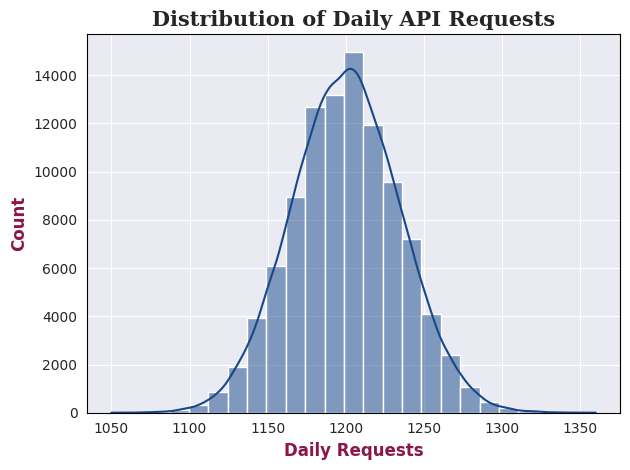

In [5]:
# Page Theme
sns.set_style('darkgrid')

# Histogram
ax = sns.histplot(x='daily_requests',data=df,bins=25,color='#16488A',kde=True)

# Styling Title and Labels
plt.title('Distribution of Daily API Requests',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Daily Requests',fontweight='bold',fontsize=12,color='#8A164A')
plt.ylabel('Count',fontweight='bold',fontsize=12,color='#8A164A')
ax.spines[:].set_color('black')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The daily_requests feature shows a near normal distribution, with most values concentrated around the middle range.
# There are fewer extreme values on both sides, indicating limited outliers.
# Since the data is fairly well distributed, it is suitable for clustering after scaling.

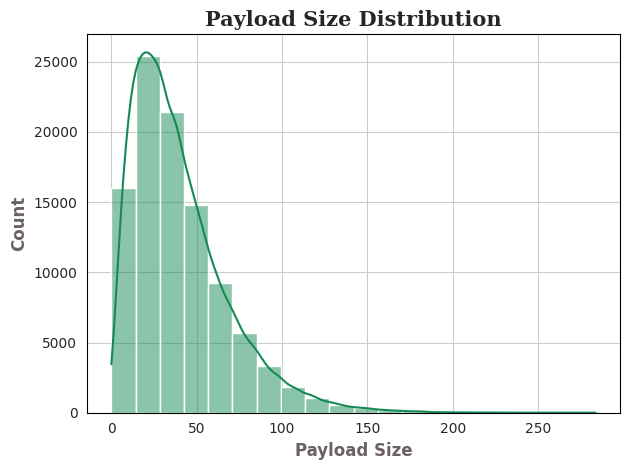

In [6]:
# Page Theme
sns.set_style('whitegrid')

# Hisplot
ax = sns.histplot(x='payload_size_kb',data=df,bins=20,color='#168A56',kde=True)

# Styling Title and Labels
plt.title('Payload Size Distribution',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Payload Size',fontweight='bold',fontsize=12,color='#6B6161')
plt.ylabel('Count',fontweight='bold',fontsize=12,color='#6B6161')
ax.spines[:].set_color('black')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The payload_size_kb feature is right-skewed, with most values concentrated at lower payload sizes.
# A small number of API requests have very large payloads, creating a long tail.
# These extreme values indicate potential outliers, which may be identified as noise in DBSCAN.
# Feature scaling is important to prevent large payload values from dominating clustering results.

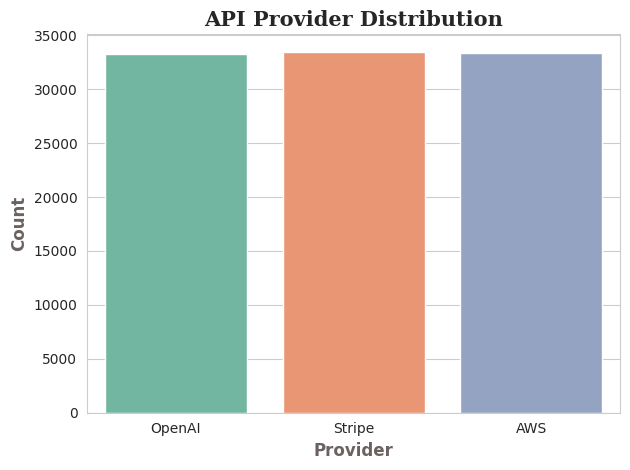

In [7]:
# Countplot
ax = sns.countplot(x='api_provider',data=df,hue='api_provider',palette='Set2')

# Styling Title and Labels
plt.title('API Provider Distribution',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Provider',fontweight='bold',fontsize=12,color='#6B6161')
plt.ylabel('Count',fontweight='bold',fontsize=12,color='#6B6161')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The dataset shows a balanced distribution across API providers (Stripe, OpenAI, AWS).
# No single provider dominates the dataset, reducing bias in clustering.
# This balanced representation helps ensure that clustering results are not influenced by one provider.

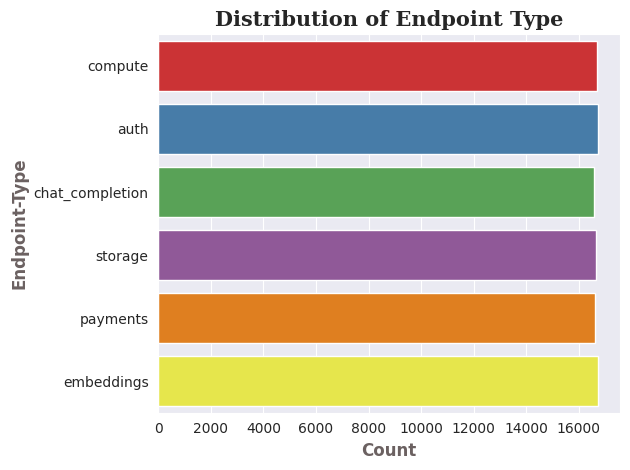

In [8]:
# Page Style
sns.set_style('darkgrid')

# Countplot
sns.countplot(y='endpoint_type',data=df,hue='endpoint_type',palette='Set1')

# Styling Title and Labels
plt.title('Distribution of Endpoint Type',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Count',fontweight='bold',fontsize=12,color='#6B6161')
plt.ylabel('Endpoint-Type',fontweight='bold',fontsize=12,color='#6B6161')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The endpoint_type distribution is relatively balanced, with no single endpoint dominating usage.
# This indicates diverse API usage patterns across applications, which is useful for meaningful clustering.

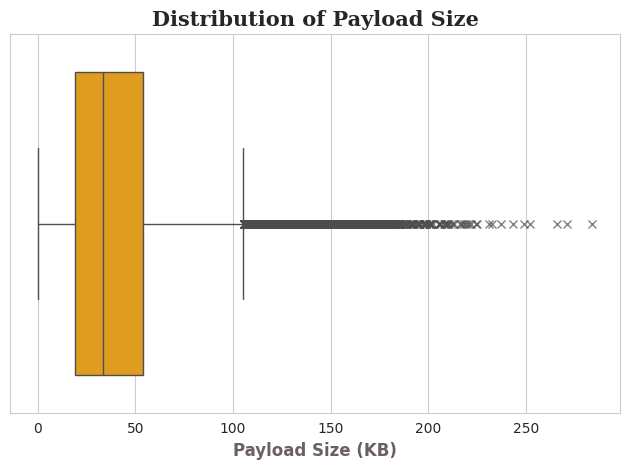

In [9]:
# Page Theme
sns.set_style('whitegrid')

# Boxplot
sns.boxplot(x='payload_size_kb',data=df,color='orange',patch_artist=True,flierprops=dict(marker='x',alpha=0.7))

# Styling Title and Labels
plt.title('Distribution of Payload Size',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Payload Size (KB)',fontweight='bold',fontsize=12,color='#6B6161')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The payload_size_kb feature shows a right-skewed distribution with several high-value outliers.
# Most API requests have smaller payload sizes, while a few have very large payloads.
# These extreme values may be treated as noise points in DBSCAN due to low density.
# Proper scaling is required to reduce the impact of large values during clustering.

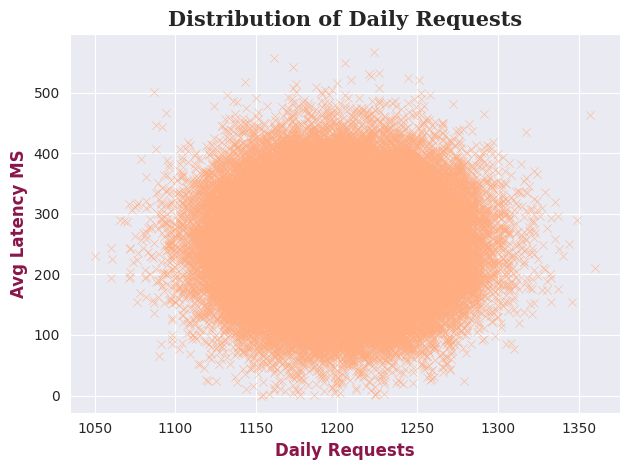

In [10]:
# Page Theme
sns.set_style('darkgrid')

# Scatterplot
sns.scatterplot(x='daily_requests',y='avg_latency_ms',data=df,color='#FFAC80',alpha=0.7,marker='x')

# Styling Title and Labels
plt.title('Distribution of Daily Requests',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Daily Requests',fontweight='bold',fontsize=12,color='#8A164A')
plt.ylabel('Avg Latency MS',fontweight='bold',fontsize=12,color='#8A164A')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Scatter plot shows a wide spread of data points, indicating no strong relationship between daily_requests and avg_latency_ms.
# Absence of a clear pattern suggests that clustering cannot rely on a single feature relationship.
# Some dense regions are visible, which may form clusters based on data density, making DBSCAN a suitable choice.

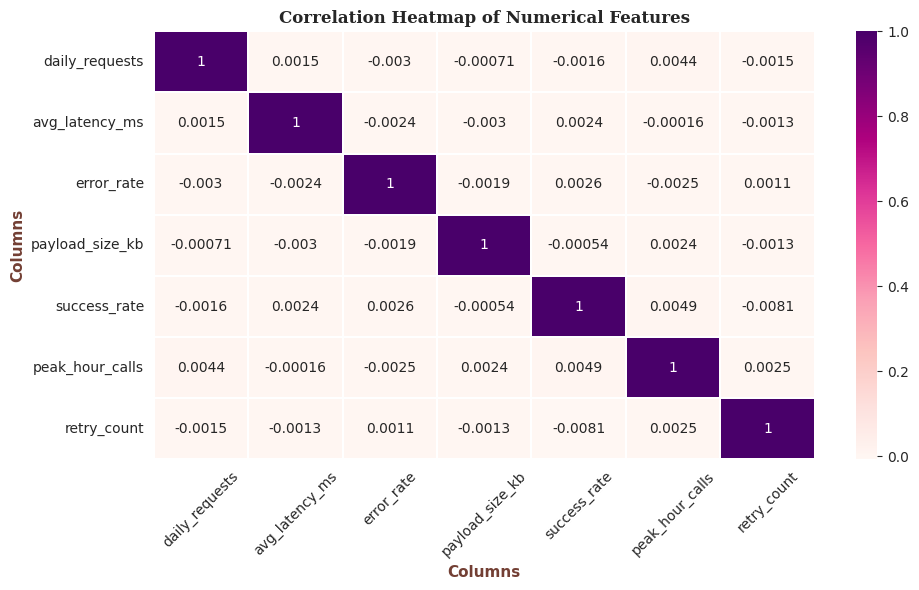

In [11]:
# Figure Size
plt.figure(figsize=(10,6))

# Heatmap
cols = df.select_dtypes(exclude='object').columns.to_list()
relation = df[cols].corr()
sns.heatmap(relation,annot=True,cmap='RdPu',linewidth=0.3)

# Styling Title and Labels
plt.title('Correlation Heatmap of Numerical Features',fontweight='bold',fontsize=12,fontfamily='Serif')
plt.xlabel('Columns',fontweight='bold',fontsize=11,color='#733F34')
plt.ylabel('Columns',fontweight='bold',fontsize=11,color='#733F34')
plt.xticks(rotation=45)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Correlation heatmap shows very low correlation between most numerical features.
# Indicates that features are largely independent, with no strong linear relationships.
# Low correlation suggests minimal redundancy, allowing each feature to contribute uniquely to clustering.
# Since clustering algorithms like DBSCAN rely on distance and density, low correlation does not negatively impact performance.

# Clusters Forming

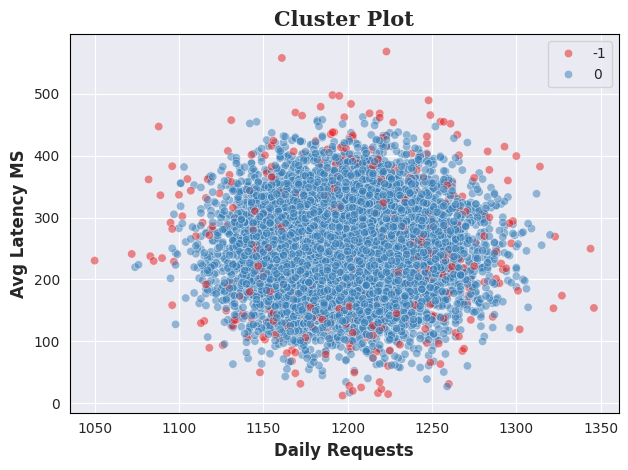

In [95]:
# DBSCAN
sampled = df.sample(frac=0.1,random_state=42)
cols = sampled.select_dtypes(exclude='object').columns.to_list()
df2 = sampled[cols]
df2 = StandardScaler().fit_transform(df2)
DBS = DBSCAN(min_samples=5,eps=1.4)
val = DBS.fit(df2)
labels = val.labels_

# Page Theme
sns.set_style('darkgrid')

# Scatterplot
ax = sns.scatterplot(x='daily_requests',y='avg_latency_ms',data=sampled,hue=labels,palette='Set1',alpha=0.5)

# Styling Title and Labels
plt.title('Cluster Plot',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Daily Requests',fontsize=12,fontweight='bold')
plt.ylabel('Avg Latency MS',fontsize=12,fontweight='bold')
ax.spines[:].set_color('black')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# DBSCAN identified one dominant cluster containing most API usage patterns.
# A small portion of data points were classified as noise(-1),representing unusual or rare API behavior.
# Absence of multiple clusters suggests dataset follows continuous distribution rather than distinct groups.

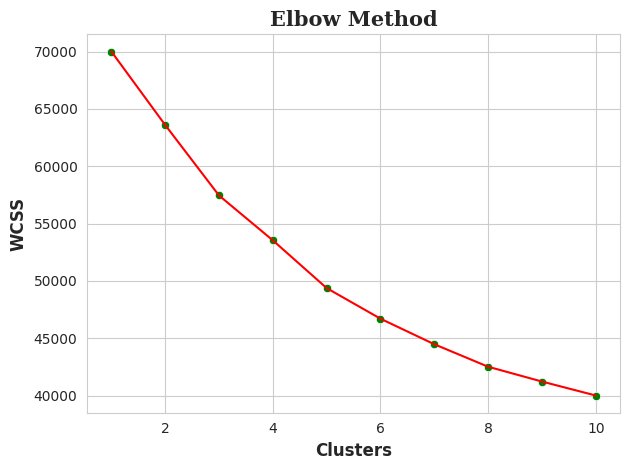

In [82]:
cols = df.select_dtypes(exclude='object').columns.to_list()
ndf = df[cols]
new_df = ndf.sample(frac=0.1,random_state=25)
scaled = StandardScaler().fit_transform(new_df)
scaled_df = pd.DataFrame(scaled,columns=cols)
wcss = []

for i in range(1,11):
  km = KMeans(n_clusters=i)
  model = km.fit_predict(scaled_df)
  n = km.inertia_
  wcss.append(n)

# Page Theme
sns.set_style('whitegrid')

# Line and Scatterplot
sns.lineplot(x=range(1,11),y=wcss,color='r')
sns.scatterplot(x=range(1,11),y=wcss,color='g')

# Styling Title and Labels
plt.title('Elbow Method',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Clusters',fontsize=12,fontweight='bold')
plt.ylabel('WCSS',fontsize=12,fontweight='bold')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# WCSS curve shows smooth decreasing trend without sharp elbow.
# This indicates weak cluster separation in dataset.
# Value of k = 3 was selected as a balanced choice for segmentation.

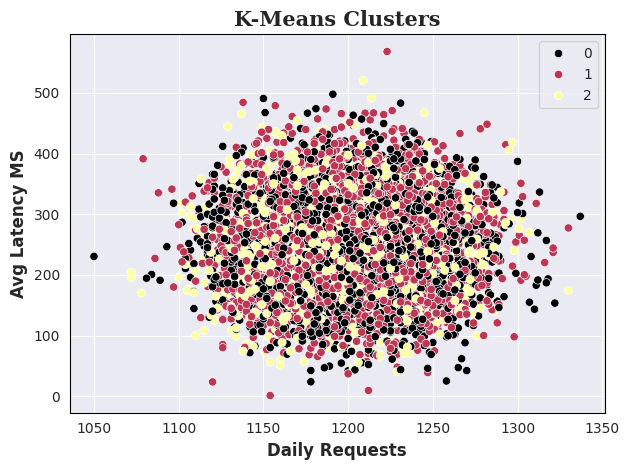

In [101]:
# Page Theme
sns.set_style('darkgrid')

# Clusters
km = KMeans(n_clusters=3,random_state=25)
model = km.fit_predict(scaled_df)

# Scatterplot
ax = sns.scatterplot(x='daily_requests',y='avg_latency_ms',data=new_df,hue=model,palette='inferno')

# Styling Title and Labels
plt.title('K-Means Clusters',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Daily Requests',fontsize=12,fontweight='bold')
plt.ylabel('Avg Latency MS',fontsize=12,fontweight='bold')
ax.spines[:].set_color('black')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# KMeans divides data into 3 clusters, creating artificial segmentation.
# Unlike DBSCAN, KMeans forces grouping even when natural clusters are not strongly present.
# These clusters can still be useful for business-level segmentation of API usage patterns.


# Evalaution

In [103]:
score = silhouette_score(scaled_df,model)
print('Silhoutte Score = ',score)

# Dataset shows weak clustering tendency. While KMeans able to segment the data into groups
# Low silhouette score indicates that clusters are not well separated and exhibit overlap.
# This Suggests that underlying data distribution is largely continuous rather than distinctly partitioned.

Silhoutte Score =  0.1127838198298718


# Final Comparison: DBSCAN vs KMeans

In [ ]:
# DBSCAN reveals the true structure of the data (one cluster + noise).
# KMeans provides practical segmentation by dividing the data into multiple groups.
# This highlights the difference between density-based clustering and partition-based clustering.

# Conclusion

In [ ]:
# Dataset does not exhibit strong natural clusters as confirmed by DBSCAN
# Results a smooth elbow curve and a low silhouette score.
# While KMeans provides segmentation into clusters,
# these groups are not well-separated
# Indicating that API usage patterns follow a continuous distribution rather than distinct segments.